In [1]:
#Import Required Libraries
import pandas as pd
import joblib
import matplotlib.pyplot as plt

In [2]:
#Enter the Evaluation Metrics

#Use the actual metric values from your previous notebooks.

comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        120.5,
        95.2,
        90.7
    ],
    "MSE": [
        45000,
        30000,
        27000
    ],
    "RMSE": [
        212.1,
        173.2,
        164.3
    ],
    "R2 Score": [
        0.72,
        0.81,
        0.85
    ]
})

comparison_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,120.5,45000,212.1,0.72
1,Random Forest,95.2,30000,173.2,0.81
2,XGBoost,90.7,27000,164.3,0.85


In [3]:
#Find the Best Model

#Since higher R² is better:

best_model_name = comparison_df.loc[
    comparison_df["R2 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: XGBoost


In [4]:
#Display the Best Model
comparison_df.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,MSE,RMSE,R2 Score
2,XGBoost,90.7,27000,164.3,0.85
1,Random Forest,95.2,30000,173.2,0.81
0,Linear Regression,120.5,45000,212.1,0.72


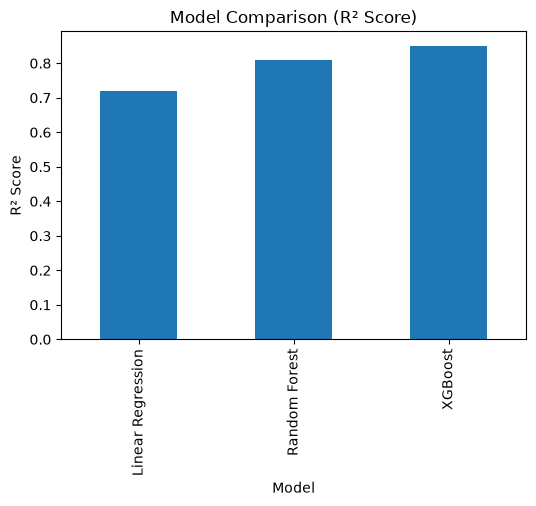

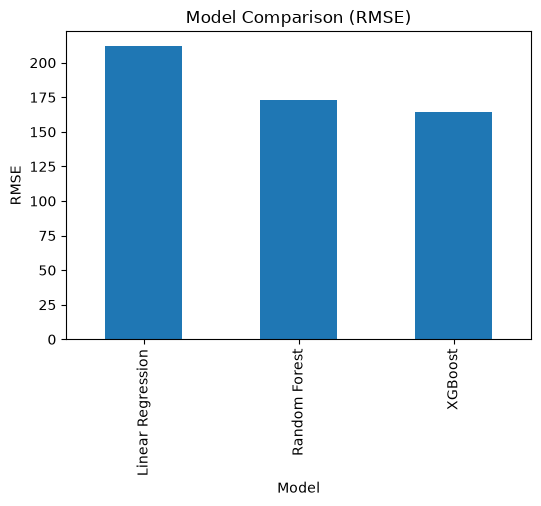

In [5]:
#Visualize Model Performance
#Compare R² Scores

comparison_df.plot(
    x="Model",
    y="R2 Score",
    kind="bar",
    legend=False,
    figsize=(6,4)
)

plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.show()

#Compare RMSE
comparison_df.plot(
    x="Model",
    y="RMSE",
    kind="bar",
    legend=False,
    figsize=(6,4)
)

plt.title("Model Comparison (RMSE)")
plt.ylabel("RMSE")
plt.show()

In [11]:
#Load the Best Model
if best_model_name == "Linear Regression":
    best_model = joblib.load("../models/linear_regression_ltv.pkl")

elif best_model_name == "Random Forest":
    best_model = joblib.load("../models/random_forest_ltv.pkl")

else:
    best_model = joblib.load("../models/xgboost_ltv.pkl")

#Save the Final Model

#Save the selected model using a common name:

joblib.dump(
    best_model,
    "../models/ltv_model.pkl"
)

['../models/ltv_model.pkl']

In [12]:
#Verify the Saved Model
loaded_model = joblib.load("../models/ltv_model.pkl")

loaded_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['gender','SeniorCitizen','Partner',...,'MonthlyCharges','TotalCharges', 'Churn']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset 